# Differential Drive Robot — System Identification

This notebook demonstrates **linear system identification** of a simplified differential drive robot using simulated data.  
The goal is to recover a discrete-time state-space model from input–output measurements, which can later be replaced with real sensor data.

---

## 1. Continuous-Time Plant Model

We model the robot with two decoupled first-order channels — **forward motion** and **turning** — each described by a DC-motor-like transfer function with time constant $\tau$ and gain $k$.

The state vector is

$$
\mathbf{x} = \begin{bmatrix} d \\ \dot{d} \\ \theta \\ \dot{\theta} \end{bmatrix},
\qquad
\mathbf{u} = \begin{bmatrix} u_{\text{fwd}} \\ u_{\text{turn}} \end{bmatrix}
$$

where $d$ is the forward distance, $\dot{d}$ the forward velocity, $\theta$ the heading angle, and $\dot{\theta}$ the angular velocity.

The continuous-time state-space matrices are

$$
A_c = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & -\frac{1}{\tau_{\text{fwd}}} & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & -\frac{1}{\tau_{\text{turn}}}
\end{bmatrix},
\qquad
B_c = \begin{bmatrix}
0 & 0 \\
\frac{k_{\text{fwd}}}{\tau_{\text{fwd}}} & 0 \\
0 & 0 \\
0 & \frac{k_{\text{turn}}}{\tau_{\text{turn}}}
\end{bmatrix}
$$

The dynamics therefore read $\dot{\mathbf{x}} = A_c\,\mathbf{x} + B_c\,\mathbf{u}$.

The model is discretised with sampling period $\Delta t$ using the exact matrix exponential:

$$
A_d = e^{A_c \Delta t}, \qquad B_d = A_c^{-1}(A_d - I)\,B_c
$$

In [1]:
import matplotlib.pyplot as plt
import AILibs
import numpy

dt = 1.0/250.0

# differential drive robot model, for forward and turn velocity control
# two servos with inertia
tau_forward = 0.1
tau_turn    = 0.03
k_forward   = 5.7
k_turn      = 7.9

mat_a = numpy.array([   [0.0, 1.0, 0.0, 0.0],
                        [0.0, -1.0/tau_forward, 0.0, 0.0],                        
                        [0.0, 0.0, 0.0, 1.0],
                        [0.0, 0.0, 0.0, -1.0/tau_turn]] )

mat_b = numpy.array(    [   [0.0, 0.0], 
                            [k_forward/tau_forward, 0.0],
                            [0.0, 0.0],
                            [0.0, k_turn/tau_turn]] )

robot_model = AILibs.DynamicalSystem(mat_a, mat_b, None, dt)


## 2. Excitation Signal Design

Good system identification requires **persistently exciting** inputs that cover the relevant frequency and amplitude range.

We use a **bang-bang** (relay) control strategy that alternates between maximum positive and negative commands, with configurable switching thresholds and wait periods:

| Channel | Strategy | Parameters |
|---------|----------|------------|
| **Turn** ($u_{\text{turn}}$) | Bang-bang between $\pm u_{\text{turn,max}}$ with progressively decreasing angular amplitude thresholds from $\theta_{\max}$ down to $\theta_{\min}$ | $u_{\text{turn,max}}=0.5$, $\theta_{\max}=40°$, $\theta_{\min}=10°$ |
| **Forward** ($u_{\text{fwd}}$) | Bang-bang between $\pm 1$ with progressively decreasing distance thresholds from $d_{\max}$ down to $d_{\min}$ | $d_{\max}=0.3\,\text{m}$, $d_{\min}=0.05\,\text{m}$ |

Between each positive and negative phase a **wait period** of fixed length is inserted ($u=0$), allowing the system to coast and reveal its natural decay (time constant).

The two channels alternate: first several turn cycles (with shrinking amplitude), then several forward cycles, then repeat. This ensures both subsystems are independently and richly excited.

### Why bang-bang?

- Maximises energy injection → high signal-to-noise ratio.
- Amplitude sweeps cover multiple operating points.
- Wait phases expose the open-loop decay, making $\tau$ identifiable.

White noise added to observations ($\sigma = 0.01$) simulates realistic sensor noise.

In [2]:
# collect data for system identification

from numpy import angle


num_samples = 10000

t_result = []
u_result = []
x_result = []

robot_model.reset()


u_turn_max = 0.5
wait_steps = 150


angle_max = 40*numpy.pi/180.0
angle_min = 10*numpy.pi/180.0

angle_ref_curr = angle_max

distance_max = 0.3
distance_min = 0.05

distance_ref_curr = distance_max


state     = 0
wait_steps_curr = 0



for n in range(num_samples):
    u = numpy.zeros((2, 1))

    angle    = robot_model.x[2, 0]
    distance = robot_model.x[0, 0]

    # turn control with bang-bang and fixed switching time
    if state == 0:
        u[1, 0] = u_turn_max
        if angle > angle_ref_curr:
            state = 1
            wait_steps_curr = wait_steps
    elif state == 1:
        u[1, 0] = 0
        wait_steps_curr -= 1
        if wait_steps_curr == 0:
            state = 2
    elif state == 2:
        u[1, 0] = -u_turn_max
        if angle < -angle_ref_curr:
            state = 3
            wait_steps_curr = wait_steps
    elif state == 3:
        u[1, 0] = 0
        wait_steps_curr -= 1
        if wait_steps_curr == 0:
            state = 0
            if angle_ref_curr > angle_min:
                angle_ref_curr-= angle_min/2.0
            else:
                angle_ref_curr = angle_max
                state = 4
    # distance control with bang-bang and fixed switching time
    elif state == 4:
        u[0, 0] = 1.0
        if distance > distance_ref_curr:
            state = 5
            wait_steps_curr = wait_steps
    elif state == 5:    
        u[0, 0] = 0.0
        wait_steps_curr -= 1
        if wait_steps_curr == 0:
            state = 6
    elif state == 6:
        u[0, 0] = -1.0
        if distance < distance_ref_curr:
            state = 7
            wait_steps_curr = wait_steps
    elif state == 7:
        u[0, 0] = 0.0
        wait_steps_curr -= 1
        if wait_steps_curr == 0:
            state = 4
            if distance_ref_curr > distance_min:
                distance_ref_curr -= (distance_max - distance_min)/5.0
            else:
                distance_ref_curr = distance_max
                state = 0
    
    x, _ = robot_model.forward_state(u)

    t_result.append(n*dt)
    u_result.append(u[:, 0])
    x_result.append(x[:, 0])

t_result = numpy.array(t_result)
u_result = numpy.array(u_result)
x_result = numpy.array(x_result)

x_noised = x_result + 0.01*numpy.random.randn(*x_result.shape)

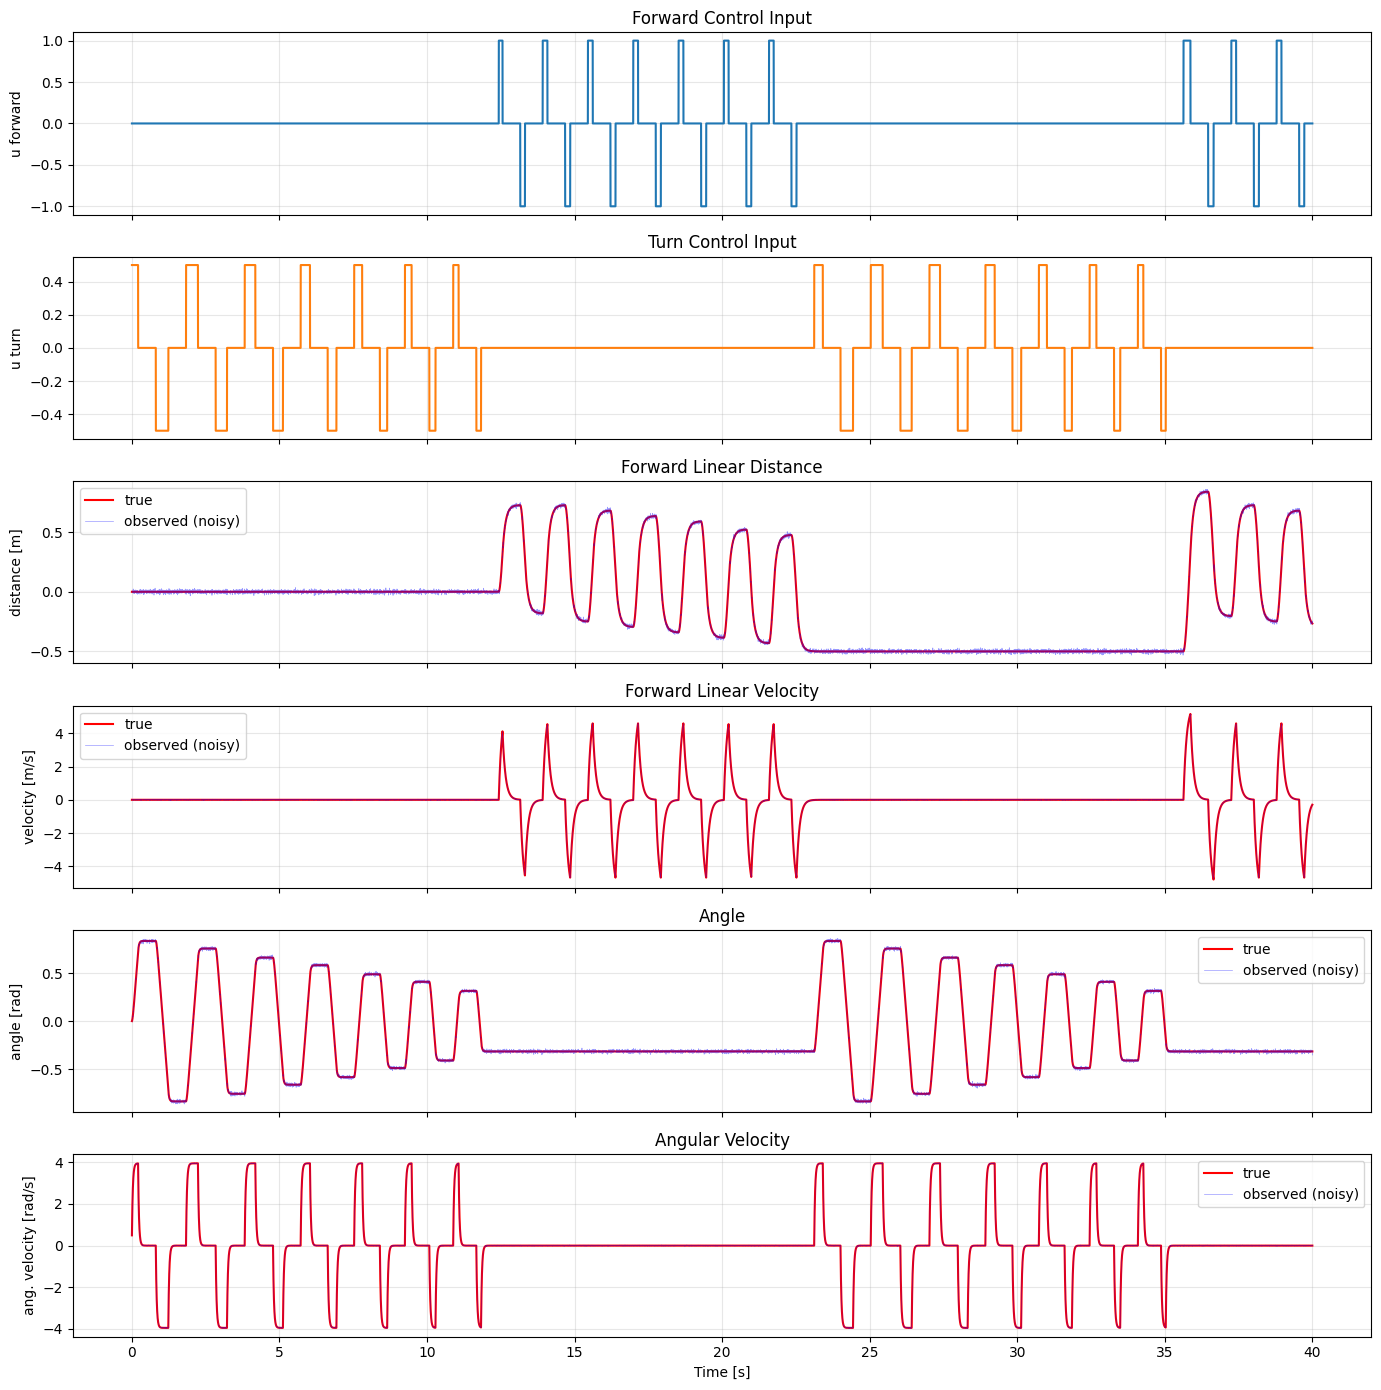

In [3]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# control input u[:, 0] - forward
axes[0].plot(t_result, u_result[:, 0], color="tab:blue")
axes[0].set_ylabel("u forward")
axes[0].set_title("Forward Control Input")
axes[0].grid(True, alpha=0.3)

# control input u[:, 1] - turn
axes[1].plot(t_result, u_result[:, 1], color="tab:orange")
axes[1].set_ylabel("u turn")
axes[1].set_title("Turn Control Input")
axes[1].grid(True, alpha=0.3)

# state x[:, 0] - forward linear distance
axes[2].plot(t_result, x_result[:, 0], label="true", color="red")
axes[2].plot(t_result, x_noised[:, 0], label="observed (noisy)", color="blue", alpha=0.4, linewidth=0.5)
axes[2].set_ylabel("distance [m]")
axes[2].set_title("Forward Linear Distance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# state x[:, 1] - forward linear velocity
axes[3].plot(t_result, x_result[:, 1], label="true", color="red")
axes[3].plot(t_result, x_noised[:, 1], label="observed (noisy)", color="blue", alpha=0.4, linewidth=0.5)
axes[3].set_ylabel("velocity [m/s]")
axes[3].set_title("Forward Linear Velocity")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# state x[:, 2] - angle
axes[4].plot(t_result, x_result[:, 2], label="true", color="red")
axes[4].plot(t_result, x_noised[:, 2], label="observed (noisy)", color="blue", alpha=0.4, linewidth=0.5)
axes[4].set_ylabel("angle [rad]")
axes[4].set_title("Angle")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# state x[:, 3] - angular velocity
axes[5].plot(t_result, x_result[:, 3], label="true", color="red")
axes[5].plot(t_result, x_noised[:, 3], label="observed (noisy)", color="blue", alpha=0.4, linewidth=0.5)
axes[5].set_ylabel("ang. velocity [rad/s]")
axes[5].set_title("Angular Velocity")
axes[5].legend()
axes[5].grid(True, alpha=0.3)

axes[5].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## 3. System Identification

Given the recorded input sequence $\mathbf{u}[k]$ and noisy state observations $\hat{\mathbf{x}}[k]$, we seek discrete-time matrices $\hat{A}_d,\,\hat{B}_d$ such that

$$
\hat{\mathbf{x}}[k+1] \approx \hat{A}_d\,\hat{\mathbf{x}}[k] + \hat{B}_d\,\mathbf{u}[k]
$$

This is cast as a **linear regression** problem.  Stacking all time steps:

$$
X' = \begin{bmatrix} \hat{A}_d & \hat{B}_d \end{bmatrix} \begin{bmatrix} X \\ U \end{bmatrix}
$$

where $X'$ contains the next-step states.  Two solvers are available:

| Solver | Description |
|--------|-------------|
| **Ordinary Least Squares (OLS)** | Minimises $\|X' - \Theta Z\|_F^2$. Fast but sensitive to noise and may yield dense matrices. |
| **SR3** (Sparse Relaxed Regularised Regression) | Promotes sparsity in $\Theta$ via a relaxed $\ell_1$ penalty, recovering the known block-sparse structure of the plant. |

We compare the identified matrices against the **reference** discretised model obtained analytically via `c2d`.

In [4]:
# system identification

# reference discretised model for comparison
A_ref, B_ref, _ = AILibs.c2d(robot_model.a, robot_model.b, None, dt)

# Simple least squares as optimizer
#optimizer = AILibs.lr_fit

# Sparse Relaxed Regularized Regression — SR3 as optimizer
optimizer = AILibs.sr3_fit

# Process identification
A_est, B_est, _ = AILibs.system_identification(u_result, x_noised, optimizer)

# --- Detailed metrics ---
err_a = numpy.abs(A_est - A_ref)
err_b = numpy.abs(B_est - B_ref)

print("=" * 60)
print("IDENTIFICATION RESULTS")
print("=" * 60)

print("\n--- A matrix ---")
print("Reference A_d:")
print(numpy.round(A_ref, 6))
print("\nIdentified A_d:")
print(numpy.round(A_est, 6))
print(f"\nFrobenius norm error  ||A_est - A_ref||_F = {numpy.linalg.norm(A_est - A_ref):.6e}")
print(f"Max element error     max|A_est - A_ref|  = {err_a.max():.6e}")
print(f"Relative error        ||ΔA||/||A_ref||    = {numpy.linalg.norm(A_est - A_ref) / numpy.linalg.norm(A_ref):.6e}")


IDENTIFICATION RESULTS

--- A matrix ---
Reference A_d:
[[1.       0.003922 0.       0.      ]
 [0.       0.960784 0.       0.      ]
 [0.       0.       1.       0.00375 ]
 [0.       0.       0.       0.875   ]]

Identified A_d:
[[ 0.99927   0.004008  0.        0.      ]
 [-0.001818  0.959744  0.        0.      ]
 [ 0.        0.        0.99952   0.003742]
 [-0.00108   0.       -0.007185  0.874705]]

Frobenius norm error  ||A_est - A_ref||_F = 7.617679e-03
Max element error     max|A_est - A_ref|  = 7.184502e-03
Relative error        ||ΔA||/||A_ref||    = 3.966271e-03


/Users/michal/projects/ai_libs/libs/AILibs/linear_regression/linear_regression.py:161: RuntimeWarning: divide by zero encountered in matmul
  XtY = X.T @ Y
/Users/michal/projects/ai_libs/libs/AILibs/linear_regression/linear_regression.py:161: RuntimeWarning: overflow encountered in matmul
  XtY = X.T @ Y
/Users/michal/projects/ai_libs/libs/AILibs/linear_regression/linear_regression.py:161: RuntimeWarning: invalid value encountered in matmul
  XtY = X.T @ Y


In [5]:

print("\n--- B matrix ---")
print("Reference B_d:")
print(numpy.round(B_ref, 6))
print("\nIdentified B_d:")
print(numpy.round(B_est, 6))
print(f"\nFrobenius norm error  ||B_est - B_ref||_F = {numpy.linalg.norm(B_est - B_ref):.6e}")
print(f"Max element error     max|B_est - B_ref|  = {err_b.max():.6e}")
print(f"Relative error        ||ΔB||/||B_ref||    = {numpy.linalg.norm(B_est - B_ref) / numpy.linalg.norm(B_ref):.6e}")



--- B matrix ---
Reference B_d:
[[4.47000e-04 0.00000e+00]
 [2.23529e-01 0.00000e+00]
 [0.00000e+00 1.97500e-03]
 [0.00000e+00 9.87500e-01]]

Identified B_d:
[[0.       0.      ]
 [0.220847 0.      ]
 [0.       0.002034]
 [0.       0.974455]]

Frobenius norm error  ||B_est - B_ref||_F = 1.332555e-02
Max element error     max|B_est - B_ref|  = 1.304496e-02
Relative error        ||ΔB||/||B_ref||    = 1.316123e-02


In [6]:

# Sparsity check (entries < 1e-4 treated as zero)
sparsity_ref = numpy.sum(numpy.abs(A_ref) < 1e-6) + numpy.sum(numpy.abs(B_ref) < 1e-6)
sparsity_est = numpy.sum(numpy.abs(A_est) < 1e-4) + numpy.sum(numpy.abs(B_est) < 1e-4)
total_params = A_ref.size + B_ref.size
print(f"\nSparsity (zero entries): reference {sparsity_ref}/{total_params},  identified {sparsity_est}/{total_params}")
print("=" * 60)


Sparsity (zero entries): reference 14/24,  identified 12/24


## 4. Model Validation — Forward Simulation

To validate the identified model we run an **open-loop forward simulation** using the identified matrices $\hat{A}_d, \hat{B}_d$ with the exact same input sequence $\mathbf{u}[k]$ and compare against the true states.

$$
\mathbf{x}_{\text{pred}}[k+1] = \hat{A}_d\,\mathbf{x}_{\text{pred}}[k] + \hat{B}_d\,\mathbf{u}[k], \qquad \mathbf{x}_{\text{pred}}[0] = \mathbf{x}[0]
$$

This is the most demanding test: any small bias in the identified matrices will **accumulate** over the full trajectory.

In [7]:
# Forward simulation with identified model
num_samples = len(u_result)
n_states = A_est.shape[0]

x_pred = numpy.zeros((num_samples, n_states))
x_pred[0] = x_result[0]  # start from true initial state

for k in range(num_samples - 1):
    x_pred[k + 1] = A_est @ x_pred[k] + B_est @ u_result[k]

# Prediction error
pred_error = x_result - x_pred
rmse_per_state = numpy.sqrt(numpy.mean(pred_error**2, axis=0))
state_labels = ["distance [m]", "velocity [m/s]", "angle [rad]", "ang. vel. [rad/s]"]

print("Open-loop forward simulation RMSE:")
for i, (label, rmse) in enumerate(zip(state_labels, rmse_per_state)):
    print(f"  x[{i}] ({label:20s}):  RMSE = {rmse:.6e}")

Open-loop forward simulation RMSE:
  x[0] (distance [m]        ):  RMSE = 2.200361e-01
  x[1] (velocity [m/s]      ):  RMSE = 4.998738e-02
  x[2] (angle [rad]         ):  RMSE = 1.298601e-01
  x[3] (ang. vel. [rad/s]   ):  RMSE = 7.379758e-02


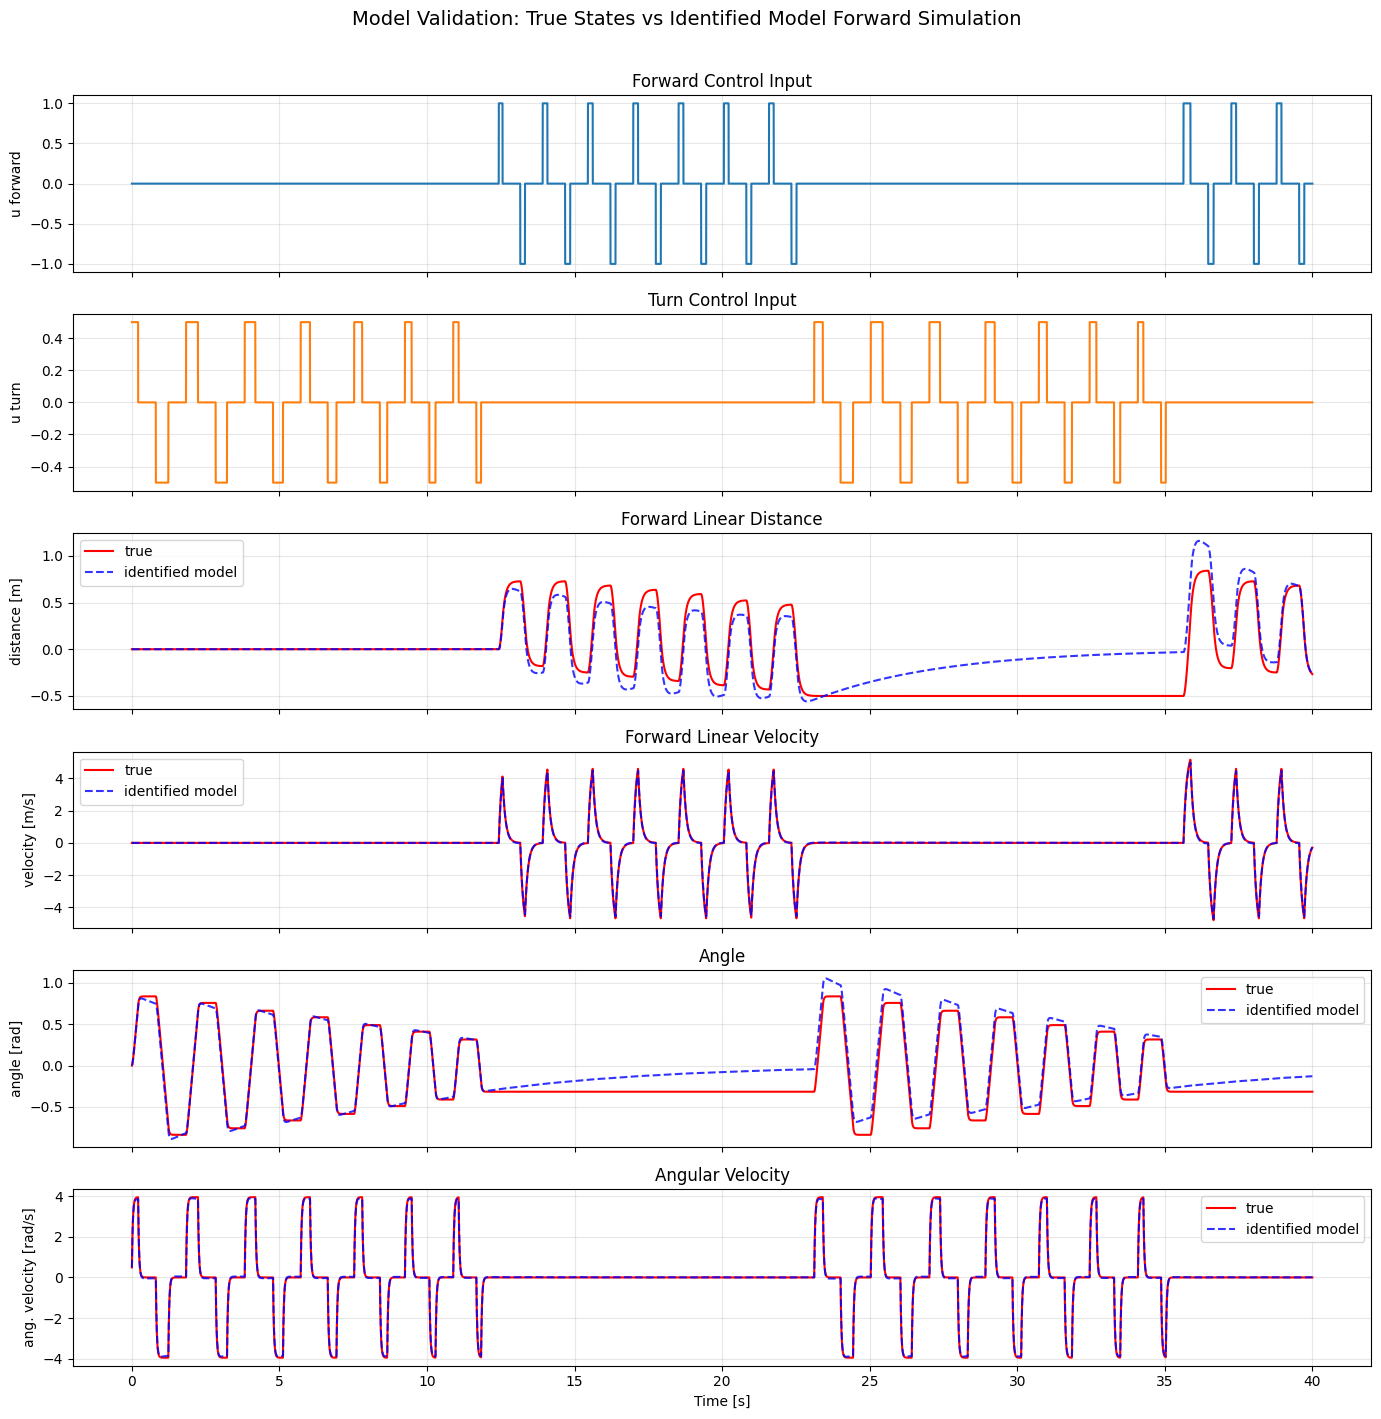

In [8]:
# Plot: true vs identified model prediction
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# control input u[:, 0] - forward
axes[0].plot(t_result, u_result[:, 0], color="tab:blue")
axes[0].set_ylabel("u forward")
axes[0].set_title("Forward Control Input")
axes[0].grid(True, alpha=0.3)

# control input u[:, 1] - turn
axes[1].plot(t_result, u_result[:, 1], color="tab:orange")
axes[1].set_ylabel("u turn")
axes[1].set_title("Turn Control Input")
axes[1].grid(True, alpha=0.3)

# state x[:, 0] - forward linear distance
axes[2].plot(t_result, x_result[:, 0], label="true", color="red")
axes[2].plot(t_result, x_pred[:, 0], label="identified model", color="blue", linestyle="--", alpha=0.8)
axes[2].set_ylabel("distance [m]")
axes[2].set_title("Forward Linear Distance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# state x[:, 1] - forward linear velocity
axes[3].plot(t_result, x_result[:, 1], label="true", color="red")
axes[3].plot(t_result, x_pred[:, 1], label="identified model", color="blue", linestyle="--", alpha=0.8)
axes[3].set_ylabel("velocity [m/s]")
axes[3].set_title("Forward Linear Velocity")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# state x[:, 2] - angle
axes[4].plot(t_result, x_result[:, 2], label="true", color="red")
axes[4].plot(t_result, x_pred[:, 2], label="identified model", color="blue", linestyle="--", alpha=0.8)
axes[4].set_ylabel("angle [rad]")
axes[4].set_title("Angle")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# state x[:, 3] - angular velocity
axes[5].plot(t_result, x_result[:, 3], label="true", color="red")
axes[5].plot(t_result, x_pred[:, 3], label="identified model", color="blue", linestyle="--", alpha=0.8)
axes[5].set_ylabel("ang. velocity [rad/s]")
axes[5].set_title("Angular Velocity")
axes[5].legend()
axes[5].grid(True, alpha=0.3)

axes[5].set_xlabel("Time [s]")

plt.suptitle("Model Validation: True States vs Identified Model Forward Simulation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()